## NDVI and Wildfires

The effects of global warming are felt everywhere. While it is hard to quantify or compare exactly all of the effects, one of the most extreme we have been seeing is the increase of wildfires in the western US. Wildfires frequency has not just been increasing, but the severity of these burns has also been increasing. According to [this NASA visualization](https://svs.gsfc.nasa.gov/5453), wildfire burned area has been increasing. This is made worse due to the increased drought stress caused by increasing temperatures.

While drought has many different definitions depending on who is talking about it, it is generally recognized as a lack of moisture in the environment causing stress. Drought can be hard to identify, but much research has been done on this topic. One method that has been developed to create a more robust system to identify drought utilizes NDVI. You can read more about this method [here](https://www.researchgate.net/profile/Lei-Ji-5/publication/284778912_Drought_monitoring_with_NDVI-based_Standardized_Vegetation_Index/links/5acce2210f7e9b189654604d/Drought-monitoring-with-NDVI-based-Standardized-Vegetation-Index.pdf).

In order to get a glimpse into this relationship, I am going to use the Waldo Canyon Fire as an area of study. The Waldo Canyon fire ignited June 23rd, 2012 and burned approximately 20,000 acres before being contained. It burned parts of El Paso and Teller counties, near Pikes Peak. According to [historical united states drought data](https://www.drought.gov/historical-information?dataset=0&selectedDateUSDM=20090707&state=Colorado&countyFips=08119), the region began seeing drought conditions September 2010 and fluxuated between abnormal dryness and extreme drought well past the fire. Lets look at NDVI leading up to this event to get an idea at what it looks like before a fire.

Everything beyond this point is going to be code. If you are not interested in that, skip to the bottom to view the results of the analysis.

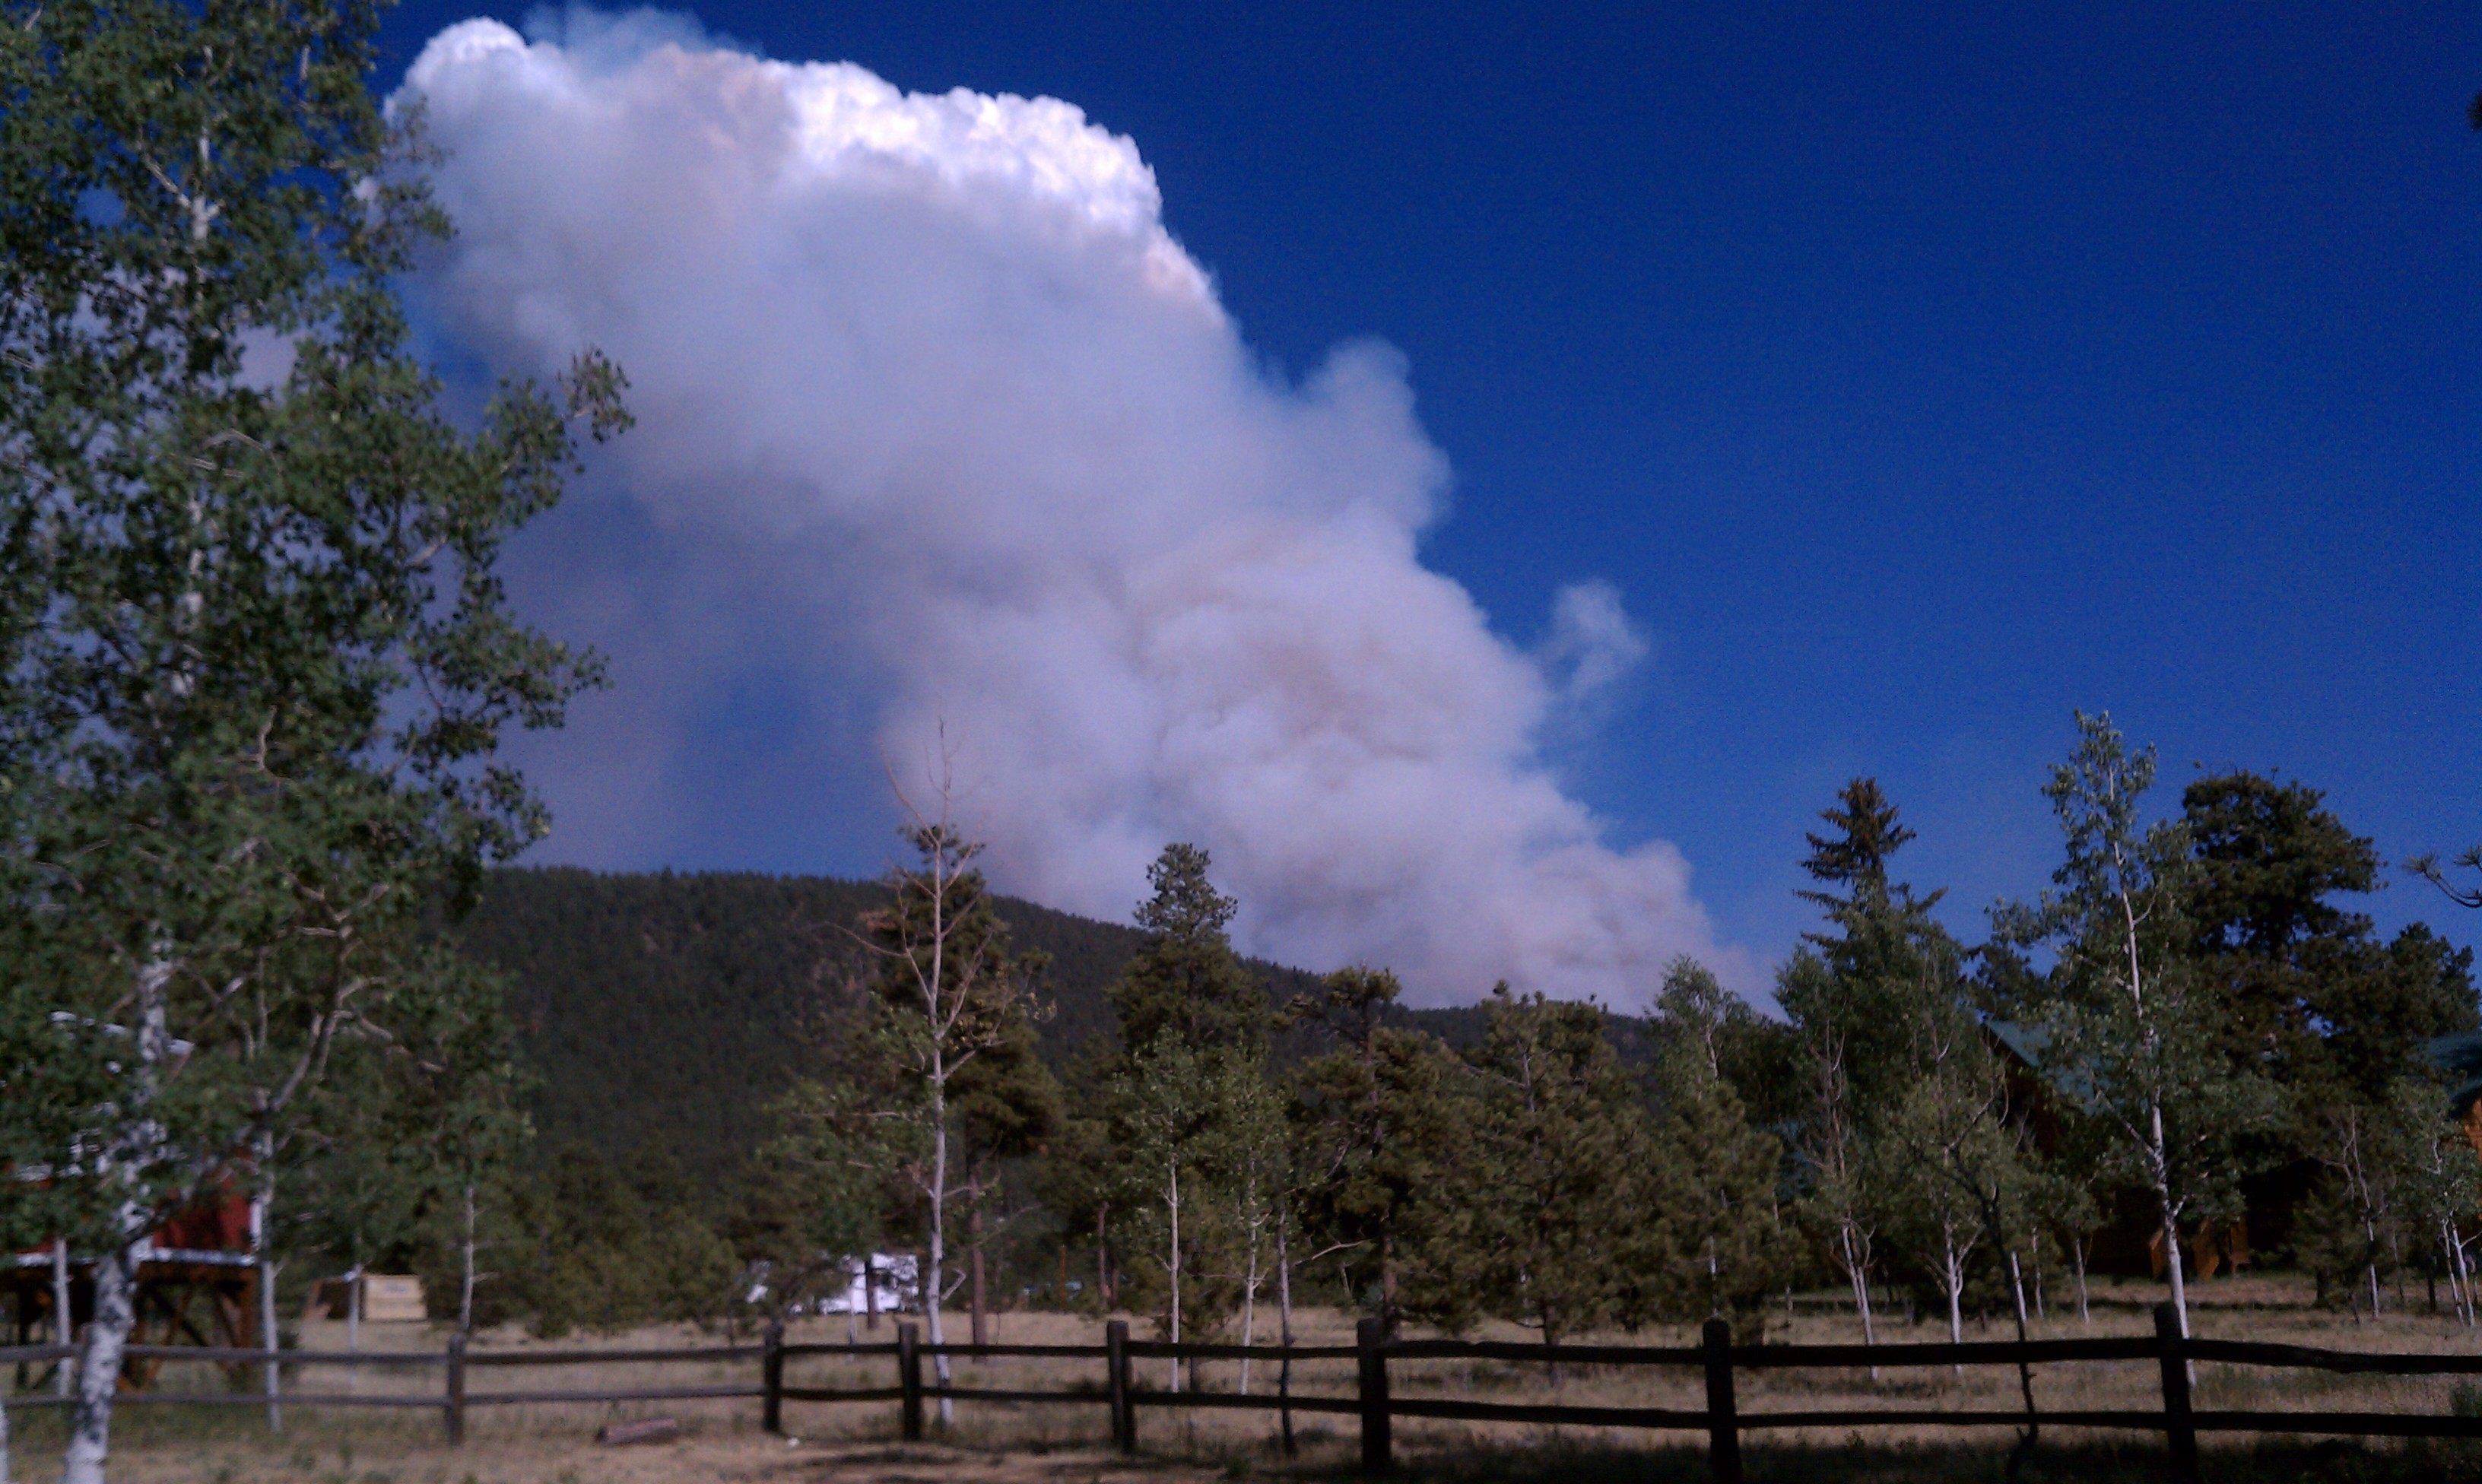
Image taken from my childhood backyard before evacuation

In [1]:
# Import packages
import geopandas as gpd # For working with shapefiles
import pathlib # For working with filesystem
import hvplot.xarray # For dynamic plotting
import hvplot.pandas # For dynamic plotting
import matplotlib.pyplot as plt # For plotting
import earthpy.api.appeears as eaapp # For working with AppEEARS API
import earthpy # For working with spatial data
import os # For working with filesystem
import xarray as xr # For working with raster data
import rioxarray as rxr # For working with spatial raster data
import pandas as pd # For working with layered arrays
import datetime # For converting julian day to standard date time

### Step 1: Get Data
First, we need to access the fire boundary. A great source for fire areas in the United States is [MTBS](https://www.mtbs.gov/). You can download an entire fire data package for any reported wildfire burned in the US. This is where I am going to source my Waldo Canyon Fire shapefile from. Move the .zip file into your data directory of choice. I recommend unzipping the file and renaming it, as it comes very nested and not with a very workable name.

In [2]:
# Define our filepaths
BASE_DATA_PATH = pathlib.Path.cwd().parent / "data"
os.makedirs(BASE_DATA_PATH, exist_ok=True)
# Define filepath for shapefile (this needs to be done seperate due to lack of python support from MTBS)
FIRE_SHAPEFILE_PATH = BASE_DATA_PATH / "waldo_canyon_burn_package/co3888410493320120623_20100918_20130926_burn_bndy.shp"
# Create earthpy project for downloading NDVI data.
project = earthpy.Project("Waldo Canyon Fire Vegetation", dirname = "waldo_canyon_fire")

In [3]:
# Read in the shapefile
fire_bounds = gpd.read_file(FIRE_SHAPEFILE_PATH).to_crs(crs="EPSG:4326")
# Check to make sure it looks right
fire_bounds.hvplot(
    geo=True, tiles='EsriImagery', 
    frame_width=500,
    legend=False, fill_color=None, edge_color='white',
    # This parameter makes all the column values in the dataset visible.
    hover_cols='all')

:Overlay
   .WMTS.I     :WMTS   [Longitude,Latitude]
   .Polygons.I :Polygons   [Longitude,Latitude]   (index,Event_ID,irwinID,Incid_Name,Incid_Type,Map_ID,Map_Prog,Asmnt_Type,BurnBndAc,BurnBndLat,BurnBndLon,Ig_Date,Pre_ID,Post_ID,Perim_ID,dNBR_offst,dNBR_stdDv,NoData_T,IncGreen_T,Low_T,Mod_T,High_T,Comment)

Now that the shapefile is loaded in, we need to download the NDVI data. 

In [4]:
# Initialize AppeearsDownloader for MODIS NDVI data
ndvi_downloader = eaapp.AppeearsDownloader(
    download_key="waldo_canyon_ndvi",
    project=project,
    product='MOD13Q1.061',
    layer='_250m_16_days_NDVI',
    start_date="07-01",
    end_date="07-31",
    recurring=True,
    year_range=[2007, 2013], 
    polygon=fire_bounds
)

In [5]:
ndvi_downloader.download_files(cache=True)

<generator object Path.rglob at 0x16a600260>

## Step 2: Wrangle the Data
Now that we have all the data we need, we need to get in into a workable format. This involves sorting through all of the .tif files downloaded, and storing them into a DataArray alongside the date of the file.

In [6]:
# Get a sorted list of NDVI tif file paths
ndvi_paths = sorted(list(project.project_dir.rglob('*NDVI*.tif')))

# Display the first and last three files paths to check the pattern
ndvi_paths[:3], ndvi_paths[-3:]

([PosixPath('/Users/keingtobin/Library/Application Support/earth-analytics/waldo_canyon_fire/waldo_canyon_ndvi/MOD13Q1.061_2007167_to_2013212/MOD13Q1.061__250m_16_days_NDVI_doy2007177000000_aid0001.tif'),
  PosixPath('/Users/keingtobin/Library/Application Support/earth-analytics/waldo_canyon_fire/waldo_canyon_ndvi/MOD13Q1.061_2007167_to_2013212/MOD13Q1.061__250m_16_days_NDVI_doy2007193000000_aid0001.tif'),
  PosixPath('/Users/keingtobin/Library/Application Support/earth-analytics/waldo_canyon_fire/waldo_canyon_ndvi/MOD13Q1.061_2007167_to_2013212/MOD13Q1.061__250m_16_days_NDVI_doy2007209000000_aid0001.tif')],
 [PosixPath('/Users/keingtobin/Library/Application Support/earth-analytics/waldo_canyon_fire/waldo_canyon_ndvi/MOD13Q1.061_2007167_to_2013212/MOD13Q1.061__250m_16_days_NDVI_doy2013177000000_aid0001.tif'),
  PosixPath('/Users/keingtobin/Library/Application Support/earth-analytics/waldo_canyon_fire/waldo_canyon_ndvi/MOD13Q1.061_2007167_to_2013212/MOD13Q1.061__250m_16_days_NDVI_doy201

In [7]:
doy_start = -25
doy_end = -18


# Loop through each NDVI image
ndvi_das = []
for ndvi_path in ndvi_paths:
    # Get date from file name
    date = str(ndvi_path)[doy_start:doy_end]
    # Convert date string to datetime object
    date = datetime.datetime.strptime(date, '%Y%j')
    # Open dataset
    da = rxr.open_rasterio(ndvi_path, mask_and_scale=True).squeeze()
    # Add date dimension and clean up metadata
    da = da.assign_coords({'date': date})
    da = da.expand_dims({'date': 1})
    da.name = 'NDVI'

    # Prepare for concatenation
    ndvi_das.append(da)

In [8]:
# Combine NDVI images from all dates
combined_ndvi_da = xr.combine_by_coords(ndvi_das, coords=['date'])
combined_ndvi_da

/var/folders/0y/hhqlb7w5069fz86snbnctjcr0000gn/T/ipykernel_72290/1663403724.py:2: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  combined_ndvi_da = xr.combine_by_coords(ndvi_das, coords=['date'])
/var/folders/0y/hhqlb7w5069fz86snbnctjcr0000gn/T/ipykernel_72290/1663403724.py:2: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  combined_ndvi

<xarray.Dataset> Size: 335kB
Dimensions:      (date: 21, y: 53, x: 75)
Coordinates:
    band         int64 8B 1
  * x            (x) float64 600B -105.0 -105.0 -105.0 ... -104.9 -104.9 -104.9
  * y            (y) float64 424B 38.98 38.98 38.98 38.98 ... 38.88 38.88 38.87
    spatial_ref  int64 8B 0
  * date         (date) datetime64[ns] 168B 2007-06-26 2007-07-12 ... 2013-07-28
Data variables:
    NDVI         (date, y, x) float32 334kB 0.692 0.692 0.692 ... 0.381 0.381

## Step 3: Analysis
Now we can use this data to preform different types of analysis.

In [9]:
# Clip the NDVI data to only be inside the fire boundary
fire_clip = combined_ndvi_da.rio.clip(fire_bounds.geometry, from_disk=True)
fire_clip

<xarray.Dataset> Size: 314kB
Dimensions:      (x: 73, y: 51, date: 21)
Coordinates:
    band         int64 8B 1
  * x            (x) float64 584B -105.0 -105.0 -105.0 ... -104.9 -104.9 -104.9
  * y            (y) float64 408B 38.98 38.98 38.98 38.97 ... 38.88 38.88 38.88
  * date         (date) datetime64[ns] 168B 2007-06-26 2007-07-12 ... 2013-07-28
    spatial_ref  int64 8B 0
Data variables:
    NDVI         (date, y, x) float32 313kB 0.6545 0.6527 nan ... nan nan nan

In [10]:
# Compute mean annual July NDVI
ndvi_means = (fire_clip # Select inside bounds
                .groupby(fire_clip.date.dt.year) #Group by the date time year
                .mean(...) # Take the mean accross all dimensions
                .NDVI # Select the NDVI variable
                .to_dataframe())['NDVI'] # Convert to dataframe

ndvi_means

year
2007    0.637241
2008    0.572468
2009    0.628934
2010    0.622582
2011    0.588587
2012    0.389066
2013    0.405215
Name: NDVI, dtype: float32

In [11]:
# Plot a line graph to inspect mean NDVI before and a little bit after the burn
ndvi_means.hvplot(title = "Mean NDVI of Waldo Canyon Burn Scar 2007-2013")

:Curve   [year]   (NDVI)

## Results

Based on the [historical united states drought data](https://www.drought.gov/historical-information?dataset=0&selectedDateUSDM=20090707&state=Colorado&countyFips=08119) provided by drought.gov, there was a period of abnormally dry conditions that covered most of El Paso County, and a small portion of Teller County beginning in Spring 2008. We can see this dip in the plot above, with a lower average NDVI in the area compared to a year without a dry spell. Despite this dry spell continuing into the winter of 2008 and early 2009, the vegetation was able to recover fairly fast, with a NDVI that looks about the same as 2007 (0.637 vs 0.629).

We begin to see a dip in NDVI again between 2010 and 2011, which correlates with a severe drought covering both Teller and El Paso counties beginning in the winter of 2010, and holding until well after the fire burned. Because the fire lit in June 2012, we see a massive dip in NDVI in the area between 2011 and 2012.

In [12]:
# Select a slice of data for 2011 and 2012 so we can map see the map of NDVI
ndvi_before = combined_ndvi_da.sel(date=slice("2011-01-01","2011-12-31"))
ndvi_after = combined_ndvi_da.sel(date=slice("2012-01-01","2022-12-31"))
# Take the mean and only grab the NDVI data
ndvi_before = ndvi_before.mean('date').NDVI
ndvi_after = ndvi_after.mean('date').NDVI

In [13]:
# Plot the NDVI before the fire
(
    ndvi_before.hvplot(x='x', y='y', cmap="PiYG", geo=True,
                    title="Average July NDVI in Waldo Canyon Burn Area \n 2011")
    *
    fire_bounds.hvplot(geo=True, fill_color=None, line_color='black')
)

:Overlay
   .Image.I    :Image   [x,y]   (NDVI)
   .Polygons.I :Polygons   [Longitude,Latitude]

In [14]:
# Plot the NDVI after the fire
(
    ndvi_after.hvplot(x='x', y='y', cmap="PiYG", geo=True,
                    title="Average July NDVI In Waldo Canyon Burn Area \n 2012",
                     xlabel="Lon", ylabel="Lat")
    *
    fire_bounds.hvplot(geo=True, fill_color=None, line_color='black')
)

:Overlay
   .Image.I    :Image   [x,y]   (NDVI)
   .Polygons.I :Polygons   [Longitude,Latitude]

As we can tell from the two plots above, the fire didn't completely wipe out all vegetation in the burn scar. Some central areas were able to make it out without too severe of burns aswell.

In [15]:
# Calculate the difference
ndvi_diff = ndvi_after - ndvi_before

# Plot the difference
(
    ndvi_diff.hvplot(x='x', y='y', cmap="PiYG", geo=True,
                    title="Difference in NDVI Before and After Burn \n 2011 vs 2012",
                     xlabel="Lon", ylabel="Lat")
    *
    fire_bounds.hvplot(geo=True, fill_color=None, line_color='black')
)

:Overlay
   .Image.I    :Image   [x,y]   (NDVI)
   .Polygons.I :Polygons   [Longitude,Latitude]

The above map gives us a good idication of the burn severity within the boundary.

## Bonus: Highway 24 Floods 2013
As many know, the affects of a wildfire are't just on the vegetation in the area. Often, there are severe affects on environments surrounding the fire. One that was seen in the year following the fire was flash flooding in the Ute Pass corridor of Highway 24. US Highway 24 was actually part of the south-western boundary of the fire, due to the fire not being able to hop the pass. Some videos of the flooding can be found [here](https://www.nbcnews.com/news/us-news/video-captures-mudslide-washing-away-car-colorado-flna6c10599717). 

The flash floods were made worse by the fire. This is due to the loss of vegetatation that would have helped slow down the flow of water. There was also a large flux of mud in the flooding, also in part due to the fire the previous year. With the increase of wildfire frequency and severity in the US West due to climate change, we need to find more ways to become resilient to issues like this that arise.